# Sentiment-Analyse von Restaurantbewertungen

## Geschäftsproblem

Ein Restaurant möchte Kundenbewertungen automatisch als positiv oder negativ klassifizieren, um Serviceprobleme schneller zu erkennen und gezielte Verbesserungen abzuleiten.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/Restaurant_Reviews.tsv", sep="\t")
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


## Überblick über den Datensatz

Der Datensatz enthält Restaurantbewertungen und eine binäre Zielvariable:

- `Review`: Text der Kundenbewertung
- `Liked`: Sentiment der Bewertung
  - `1` = positive Bewertung
  - `0` = negative Bewertung

In [7]:
print("Erste Zeilen")
print(df.head())

print("\nInformationen zum Datensatz:")
print(df.info())

print("\nVerteilung der Zielvariable:")
print(df["Liked"].value_counts())

df["review_length"] = df["Review"].apply(len)
df["word_count"] = df["Review"].apply(lambda text: len(text.split()))

print("\nStatistik zur Bewertungslänge:")
print(df[["review_length", "word_count"]].describe())



Erste Zeilen
                                              Review  Liked  review_length  \
0                           Wow... Loved this place.      1             24   
1                                 Crust is not good.      0             18   
2          Not tasty and the texture was just nasty.      0             41   
3  Stopped by during the late May bank holiday of...      1             87   
4  The selection on the menu was great and so wer...      1             59   

   word_count  
0           4  
1           4  
2           8  
3          15  
4          12  

Informationen zum Datensatz:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Review         1000 non-null   str  
 1   Liked          1000 non-null   int64
 2   review_length  1000 non-null   int64
 3   word_count     1000 non-null   int64
dtypes: int64(3), str(1)
memory usage: 31.4 KB

Mit `apply(len)` wird für jede Bewertung gezählt, aus wie vielen Zeichen sie besteht.
Mit `text.split()` wird der Text an Leerzeichen getrennt. Dadurch entsteht eine Liste einzelner Wörter. Mit `len(...)` wird anschließend gezählt, wie viele Wörter die Bewertung enthält.

Die Funktion `describe()` liefert statistische Kennzahlen wie Mittelwert, Minimum, Maximum und Quartile. Dadurch bekommt man einen schnellen Überblick darüber, wie kurz oder lang die Bewertungen im Datensatz typischerweise sind.

In [10]:
df.isnull().sum()

Review    0
Liked     0
dtype: int64

Der Datensatz enthält 1000 Bewertungen. Es gibt keine fehlenden Werte.
Die Zielvariable ist vollständig ausgeglichen: 500 positive und 500 negative Bewertungen.

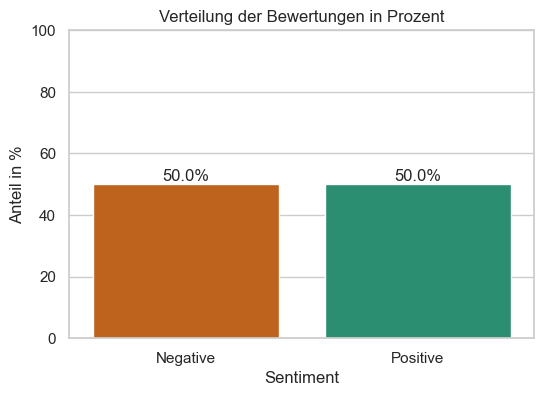

In [11]:
# prozentuale Verteilung
sentiment_counts = df["Liked"].value_counts().sort_index()
sentiment_percentages = sentiment_counts / sentiment_counts.sum() * 100

plt.figure(figsize=(6, 4))
sns.barplot(
    x=["Negative", "Positive"],
    y=sentiment_percentages.values,
    hue=["Negative", "Positive"],
    palette=["#d95f02", "#1b9e77"],
    legend=False
)

plt.title("Verteilung der Bewertungen in Prozent")
plt.xlabel("Sentiment")
plt.ylabel("Anteil in %")
plt.ylim(0, 100)

for index, value in enumerate(sentiment_percentages.values):
    plt.text(index, value + 1, f"{value:.1f}%", ha="center")

plt.show()

In [12]:
# Bewertungslänge berechnen
df["review_length"] = df["Review"].apply(len)
df["word_count"] = df["Review"].apply(lambda text: len(text.split()))

df[["review_length","word_count"]].describe()

,review_length,word_count
count,1000.000000,1000.000000
mean,58.315000,10.894000
std,32.360052,6.257469
min,11.000000,1.000000
25%,33.000000,6.000000
50%,51.000000,10.000000
75%,80.000000,15.000000
max,149.000000,32.000000


## Analyse der Bewertungslänge

Neben der reinen Sentiment-Verteilung ist auch die Länge der Bewertungen interessant.
Längere Bewertungen können darauf hindeuten, dass Kundinnen und Kunden ausführlicher über besonders positive oder negative Erfahrungen berichten.

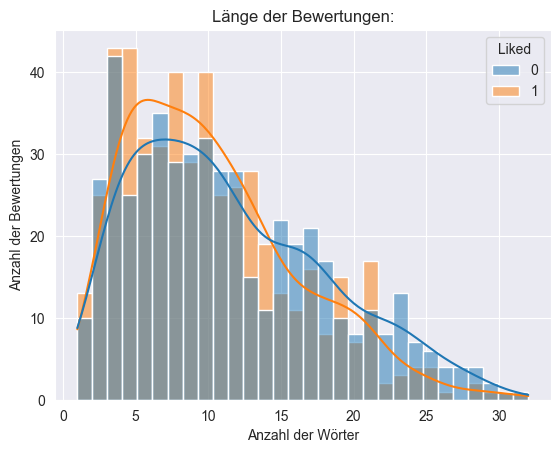


Beispiele negativer Bewertungen:
1                                    Crust is not good.
2             Not tasty and the texture was just nasty.
5        Now I am getting angry and I want my damn pho.
6                 Honeslty it didn't taste THAT fresh.)
7     The potatoes were like rubber and you could te...
11                                   Would not go back.
12    The cashier had no care what so ever on what I...
14    I was disgusted because I was pretty sure that...
15    I was shocked because no signs indicate cash o...
17               Waitress was a little slow in service.
Name: Review, dtype: str

Beispiele positiver Bewertungen:
0                              Wow... Loved this place.
3     Stopped by during the late May bank holiday of...
4     The selection on the menu was great and so wer...
8                             The fries were great too.
9                                        A great touch.
10                             Service was very prompt.
13    I tri

In [8]:
sns.histplot(data=df, x="word_count", hue="Liked", bins=30, kde=True)
plt.title("Länge der Bewertungen:")
plt.xlabel("Anzahl der Wörter")
plt.ylabel("Anzahl der Bewertungen")
plt.show()

print("\nBeispiele negativer Bewertungen:")
print(df[df["Liked"] == 0]["Review"].head(10))

print("\nBeispiele positiver Bewertungen:")
print(df[df["Liked"] == 1]["Review"].head(10))

`plt.figure(figsize=(8, 5))` legt die Größe der Grafik fest.

`sns.histplot()` erstellt ein Histogramm. Dabei wird auf der x-Achse die Anzahl der Wörter pro Bewertung dargestellt.
Mit `hue="Liked"` werden positive und negative Bewertungen farblich getrennt. Dadurch kann man beide Gruppen direkt vergleichen.

`bins=30` bedeutet, dass die Werte in 30 Bereiche eingeteilt werden.
`kde=True` fügt zusätzlich eine geglättete Kurve hinzu, die den allgemeinen Verlauf der Verteilung besser sichtbar macht.

Die Achsenbeschriftungen und der Titel sorgen dafür, dass die Grafik auch ohne zusätzlichen Code verständlich ist.

### Verteilung der Bewertungslängen

Das Histogramm zeigt, wie häufig bestimmte Bewertungslängen vorkommen.
Durch die farbliche Trennung nach Sentiment lässt sich erkennen, ob positive und negative Bewertungen unterschiedlich lang sind.

### Vergleich der Bewertungslängen nach Sentiment

Der Boxplot fasst die Bewertungslängen kompakt zusammen und zeigt Median, Streuung und mögliche Ausreißer.

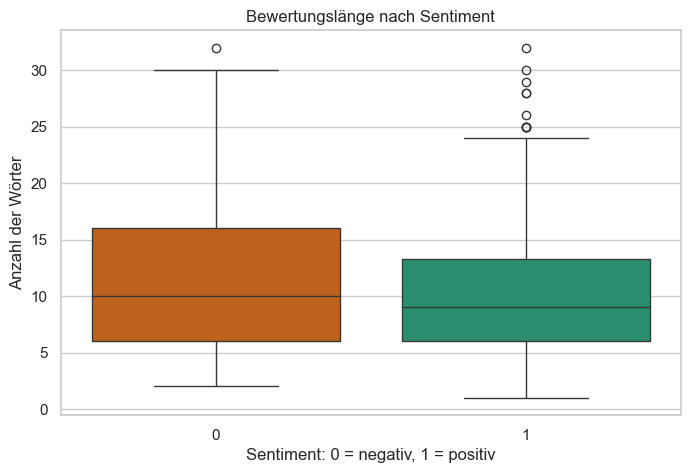

In [13]:
# Bewertungslänge visualisieren
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Liked",
    y="word_count",
    hue="Liked",
    palette=["#d95f02", "#1b9e77"],
    legend=False
)

plt.title("Bewertungslänge nach Sentiment")
plt.xlabel("Sentiment: 0 = negativ, 1 = positiv")
plt.ylabel("Anzahl der Wörter")
plt.show()

Der Boxplot vergleicht die Anzahl der Wörter zwischen negativen und positiven Bewertungen.

Auf der x-Achse steht das Sentiment (`0` = negativ, `1` = positiv).
Auf der y-Achse steht die Anzahl der Wörter pro Bewertung.

Die Linie innerhalb der Box zeigt den Median. Das ist der mittlere Wert der Bewertungslänge.
Die Box zeigt den Bereich, in dem die mittleren 50 % der Werte liegen.
Punkte außerhalb der Box können Ausreißer darstellen, also besonders lange Bewertungen.

So lässt sich schnell erkennen, ob eine Gruppe tendenziell längere oder kürzere Bewertungen schreibt.

Die meisten Bewertungen sind relativ kurz. Positive und negative Bewertungen unterscheiden sich in ihrer Länge nicht stark, es gibt jedoch einzelne längere Bewertungen in beiden Klassen.
Daher reicht die Bewertungslänge allein wahrscheinlich nicht aus, um das Sentiment zuverlässig vorherzusagen. Für die Modellierung ist der tatsächliche Textinhalt entscheidender.

## Textvorverarbeitung

Bevor die Bewertungen für ein Machine-Learning-Modell genutzt werden können, müssen die Texte bereinigt werden.

Ziel der Textvorverarbeitung ist es, unnötige Zeichen zu entfernen und die Texte in eine einheitliche Form zu bringen. Dadurch kann das Modell besser relevante Muster erkennen.

In diesem Projekt werden folgende Schritte durchgeführt:

- Umwandlung in Kleinbuchstaben
- Entfernen von Sonderzeichen und Zahlen
- Aufteilen des Textes in einzelne Wörter
- Entfernen englischer Stoppwörter
- Zusammenfügen der bereinigten Wörter zu einem neuen Text

In [14]:
# benötigte Bibliotheken
import re
import nltk

from nltk.corpus import stopwords

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/michaelakittel/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Für die Textbereinigung werden zwei zusätzliche Bibliotheken verwendet:

`re` ist eine Python-Bibliothek für reguläre Ausdrücke. Damit können bestimmte Zeichenmuster aus Texten entfernt werden.

`nltk` ist eine bekannte Bibliothek für Natural Language Processing. In diesem Projekt wird sie verwendet, um englische Stoppwörter zu entfernen.

Stoppwörter sind sehr häufige Wörter wie "the", "and", "is" oder "a". Diese Wörter tragen oft wenig zur Bedeutung einer Bewertung bei und können deshalb entfernt werden.

In [15]:
# cleaning-Funktion
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

Die Funktion `clean_text()` bereinigt eine einzelne Bewertung Schritt für Schritt.

Zuerst wird der Text mit `lower()` in Kleinbuchstaben umgewandelt. Dadurch werden Wörter wie "Good" und "good" gleich behandelt.

Mit `re.sub(r"[^a-z\s]", "", text)` werden alle Zeichen entfernt, die keine englischen Buchstaben oder Leerzeichen sind. Satzzeichen, Zahlen und Sonderzeichen werden dadurch gelöscht.

Anschließend wird der Text mit `split()` in einzelne Wörter aufgeteilt.

Die Listen-Abfrage entfernt alle Wörter, die in der Liste der englischen Stoppwörter enthalten sind.

Am Ende werden die übrigen Wörter mit `" ".join(words)` wieder zu einem bereinigten Text zusammengesetzt.

In [16]:
# Funktion anwenden
df["cleaned_review"] = df["Review"].apply(clean_text)
df[["Review", "cleaned_review", "Liked"]].head(10)

# Die Bereinigungsfunktion wird mit `apply(clean_text)` auf jede Bewertung in der Spalte `Review` angewendet.
# Das Ergebnis wird in einer neuen Spalte `cleaned_review` gespeichert.
# Dadurch bleibt der Originaltext erhalten, und die bereinigte Version kann später für das Modelltraining genutzt werden.

,Review,cleaned_review,Liked
0,Wow... Loved this place.,wow loved place,1
1,Crust is not good.,crust good,0
2,Not tasty and the texture was just nasty.,tasty texture nasty,0
3,Stopped by during the late May bank holiday of...,stopped late may bank holiday rick steve recom...,1
4,The selection on the menu was great and so wer...,selection menu great prices,1
5,Now I am getting angry and I want my damn pho.,getting angry want damn pho,0
6,Honeslty it didn't taste THAT fresh.),honeslty didnt taste fresh,0
7,The potatoes were like rubber and you could te...,potatoes like rubber could tell made ahead tim...,0
8,The fries were great too.,fries great,1
9,A great touch.,great touch,1


In [17]:
 # Vorher-Nachher-Beispiele

 for index in range(5):
     print("Orginal:")
     print(df.loc[index, "Review"])
     print("Bereinigt:")
     print(df.loc[index, "cleaned_review"])
     print("-" * 80)

Orginal:
Wow... Loved this place.
Bereinigt:
wow loved place
--------------------------------------------------------------------------------
Orginal:
Crust is not good.
Bereinigt:
crust good
--------------------------------------------------------------------------------
Orginal:
Not tasty and the texture was just nasty.
Bereinigt:
tasty texture nasty
--------------------------------------------------------------------------------
Orginal:
Stopped by during the late May bank holiday off Rick Steve recommendation and loved it.
Bereinigt:
stopped late may bank holiday rick steve recommendation loved
--------------------------------------------------------------------------------
Orginal:
The selection on the menu was great and so were the prices.
Bereinigt:
selection menu great prices
--------------------------------------------------------------------------------


Durch die Textbereinigung werden die Bewertungen kürzer und einheitlicher.
Unwichtige Wörter und Sonderzeichen werden entfernt, während zentrale Begriffe wie "loved", "good", "tasty" oder "nasty" erhalten bleiben.

Diese bereinigten Texte bilden die Grundlage für das spätere Feature Engineering mit TF-IDF.

## Häufige Wörter in positiven und negativen Bewertungen

Um besser zu verstehen, welche Begriffe mit positiven oder negativen Erfahrungen verbunden sind, werden die häufigsten Wörter getrennt nach Sentiment analysiert.

Diese Analyse kann Hinweise darauf geben, welche Aspekte Kundinnen und Kunden besonders häufig loben oder kritisieren.

In [18]:
from collections import Counter

positive_words = " ".join(df[df["Liked"] == 1]["cleaned_review"]).split()
negative_words = " ".join(df[df["Liked"] == 0]["cleaned_review"]).split()

positive_word_counts = Counter(positive_words)
negative_word_counts = Counter(negative_words)

positive_common_words = positive_word_counts.most_common(15)
negative_common_words = negative_word_counts.most_common(15)

positive_common_words, negative_common_words

([('good', 73),
  ('great', 70),
  ('food', 60),
  ('place', 57),
  ('service', 46),
  ('friendly', 23),
  ('delicious', 23),
  ('back', 23),
  ('nice', 22),
  ('time', 22),
  ('really', 22),
  ('best', 22),
  ('amazing', 21),
  ('also', 18),
  ('like', 17)],
 [('food', 64),
  ('place', 49),
  ('back', 38),
  ('service', 37),
  ('like', 29),
  ('go', 26),
  ('dont', 25),
  ('good', 22),
  ('never', 22),
  ('would', 21),
  ('time', 20),
  ('ever', 19),
  ('minutes', 19),
  ('bad', 18),
  ('one', 16)])

Zuerst werden alle bereinigten positiven Bewertungen zu einem langen Text verbunden. Danach wird dieser Text wieder in einzelne Wörter aufgeteilt.

Dasselbe wird für die negativen Bewertungen gemacht.

Mit `Counter` wird gezählt, wie häufig jedes Wort vorkommt.
`most_common(15)` gibt anschließend die 15 häufigsten Wörter zurück.

So können positive und negative Bewertungen direkt miteinander verglichen werden.

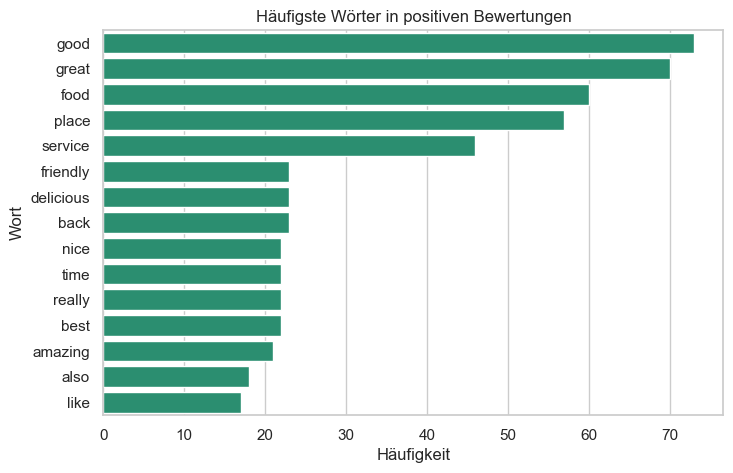

In [19]:
# positive Wörter visualisieren
positive_words_df = pd.DataFrame(
    positive_common_words,
    columns=["word", "count"]
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=positive_words_df,
    x="count",
    y="word",
    color="#1b9e77"
)

plt.title("Häufigste Wörter in positiven Bewertungen")
plt.xlabel("Häufigkeit")
plt.ylabel("Wort")
plt.show()

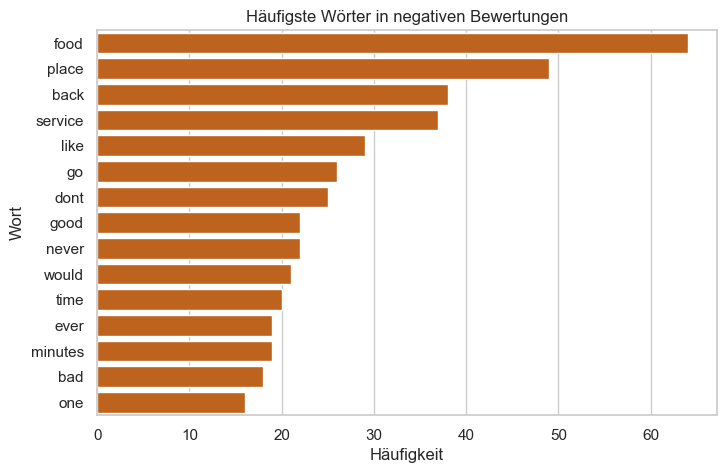

In [20]:
# negative Wörter visualisieren
negative_words_df = pd.DataFrame(
    negative_common_words,
    columns=["word", "count"]
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=negative_words_df,
    x="count",
    y="word",
    color="#d95f02"
)

plt.title("Häufigste Wörter in negativen Bewertungen")
plt.xlabel("Häufigkeit")
plt.ylabel("Wort")
plt.show()

Die häufigsten Wörter werden in zwei Balkendiagrammen dargestellt.

Für die Visualisierung werden die gezählten Wörter zunächst in DataFrames umgewandelt.
Dadurch können sie einfach mit `seaborn.barplot()` dargestellt werden.

Die x-Achse zeigt, wie häufig ein Wort vorkommt.
Die y-Achse zeigt das jeweilige Wort.

Durch die getrennte Darstellung positiver und negativer Bewertungen lassen sich typische Begriffe für beide Gruppen erkennen.

Die häufigsten Wörter geben erste Hinweise darauf, welche Themen in den Bewertungen besonders präsent sind.

Positive Bewertungen enthalten typischerweise Wörter, die auf Zufriedenheit mit Essen, Service oder Atmosphäre hindeuten.
Negative Bewertungen enthalten häufiger Begriffe, die mit Enttäuschung, schlechtem Geschmack, Wartezeit oder Serviceproblemen verbunden sein können.

Diese Erkenntnisse sind aus geschäftlicher Sicht relevant, da sie dem Restaurant helfen können, wiederkehrende Stärken und Schwächen zu erkennen.

Falls allgemeine Wörter wie food, place oder service in beiden Gruppen stark vorkommen, ist das normal. Dann interpretieren wir nicht jedes häufige Wort einzeln, sondern schauen auf Unterschiede zwischen positiv und negativ.

## Feature Engineering mit TF-IDF

Machine-Learning-Modelle können Text nicht direkt verarbeiten. Deshalb müssen die bereinigten Bewertungen in numerische Merkmale umgewandelt werden.

In diesem Projekt wird dafür TF-IDF verwendet.

TF-IDF steht für `Term Frequency - Inverse Document Frequency`.
Diese Methode bewertet Wörter danach, wie wichtig sie für einzelne Dokumente im Vergleich zum gesamten Datensatz sind.

Ein Wort erhält einen höheren Wert, wenn es in einer Bewertung häufig vorkommt, aber im gesamten Datensatz nicht überall erscheint. Dadurch werden aussagekräftige Wörter stärker gewichtet als sehr allgemeine Wörter.

In [21]:
X = df["cleaned_review"]
y = df["Liked"]

# `X` enthält die Eingabedaten für das Modell. In diesem Fall sind das die bereinigten Bewertungen.
# `y` enthält die Zielvariable, also das Sentiment der Bewertung:
# - `0` = negative Bewertung
# - `1` = positive Bewertung

In [25]:
# Trainings- und Testdaten aufteilen
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1500)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Der Datensatz wird in Trainings- und Testdaten aufgeteilt.

Das Modell lernt mit den Trainingsdaten und wird anschließend auf den Testdaten bewertet.
Dadurch kann geprüft werden, wie gut das Modell auf neuen, bisher unbekannten Bewertungen funktioniert.

`test_size=0.2` bedeutet, dass 20 % der Daten für den Test verwendet werden und 80 % für das Training.

`random_state=42` sorgt dafür, dass die Aufteilung reproduzierbar bleibt. Bei erneutem Ausführen entsteht also dieselbe Aufteilung.

`stratify=y` stellt sicher, dass positive und negative Bewertungen im Trainings- und Testset im gleichen Verhältnis vorkommen.

Mit `TfidfVectorizer` werden die bereinigten Texte in numerische Merkmale umgewandelt.

`max_features=1500` begrenzt die Anzahl der verwendeten Wörter auf die 1500 wichtigsten Merkmale. Dadurch bleibt das Modell übersichtlicher und weniger anfällig für Rauschen.

`fit_transform(X_train)` lernt das Vokabular aus den Trainingsdaten und wandelt diese direkt in TF-IDF-Werte um.

`transform(X_test)` verwendet dasselbe gelernte Vokabular für die Testdaten.
Wichtig ist, dass `fit_transform()` nur auf den Trainingsdaten verwendet wird, damit keine Informationen aus den Testdaten in das Training gelangen.

In [29]:
# Dimensionen prüfen
print("Trainingsdaten:", X_train_tfidf.shape)
print("Testdaten:", X_test_tfidf.shape)

# Die Ausgabe zeigt, wie viele Bewertungen und wie viele numerische Merkmale nach der TF-IDF-Umwandlung vorhanden sind.
# Die erste Zahl steht für die Anzahl der Bewertungen.
# Die zweite Zahl steht für die Anzahl der verwendeten Textmerkmale.

Trainingsdaten: (800, 1500)
Testdaten: (200, 1500)


## Modelltraining: Logistic Regression

Als erstes Modell wird eine logistische Regression verwendet.

Obwohl der Name "Regression" enthält, wird dieses Verfahren häufig für Klassifikationsprobleme eingesetzt.
In diesem Projekt soll das Modell vorhersagen, ob eine Bewertung positiv oder negativ ist.

Logistic Regression eignet sich gut als Basismodell, weil es schnell trainiert, gut interpretierbar ist und bei TF-IDF-Textmerkmalen häufig solide Ergebnisse liefert.

In [30]:
# Modell trainieren
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train_tfidf, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Mit `LogisticRegression()` wird das Modell erstellt.

`max_iter=1000` erhöht die maximale Anzahl der Trainingsdurchläufe. Das hilft, damit das Modell zuverlässig konvergiert.

Mit `fit(X_train_tfidf, y_train)` wird das Modell trainiert.
Dabei lernt es Zusammenhänge zwischen den TF-IDF-Merkmalen der Bewertungen und dem jeweiligen Sentiment.

In [31]:
# Vorhersage erstellen
y_pred_log_reg = log_reg.predict(X_test_tfidf)

# Nach dem Training wird das Modell auf die Testdaten angewendet.
#`predict(X_test_tfidf)` erstellt für jede Bewertung im Testset eine Vorhersage:
# - `0` = negativ
# - `1` = positiv
# Diese Vorhersagen werden anschließend mit den tatsächlichen Labels aus `y_test` verglichen.

## Bewertung des Logistic-Regression-Modells

Zur Bewertung des Modells werden mehrere Metriken verwendet:

- Accuracy: Anteil aller korrekt klassifizierten Bewertungen
- Precision: Anteil korrekt vorhergesagter positiver Bewertungen unter allen als positiv vorhergesagten Bewertungen
- Recall: Anteil korrekt erkannter positiver Bewertungen unter allen tatsächlich positiven Bewertungen
- F1-Score: Kombination aus Precision und Recall

In [32]:
# classification Report
from sklearn.metrics import accuracy_score, classification_report

accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)

print("Accuracy:", accuracy_log_reg)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))


Accuracy: 0.795

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79       100
           1       0.78      0.82      0.80       100

    accuracy                           0.80       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.80      0.79       200



`accuracy_score()` berechnet den Anteil der korrekt klassifizierten Bewertungen.

`classification_report()` zeigt zusätzlich Precision, Recall und F1-Score für beide Klassen.

Das ist besonders wichtig, weil Accuracy allein manchmal zu wenig aussagt.
Für das Restaurant ist es zum Beispiel wichtig, negative Bewertungen zuverlässig zu erkennen, damit Serviceprobleme nicht übersehen werden.

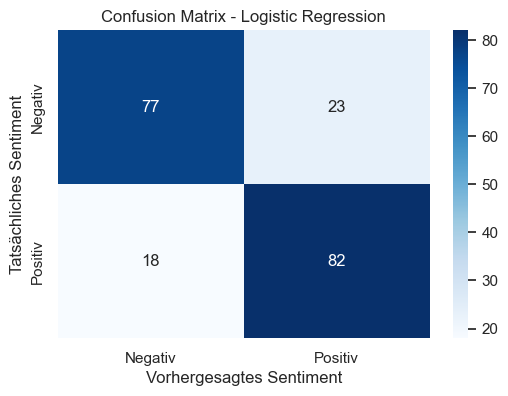

In [33]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_log_reg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negativ", "Positiv"],
    yticklabels=["Negativ", "Positiv"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Vorhergesagtes Sentiment")
plt.ylabel("Tatsächliches Sentiment")
plt.show()


Die Confusion Matrix zeigt, welche Bewertungen richtig und falsch klassifiziert wurden.

Die Zeilen stehen für die tatsächlichen Klassen.
Die Spalten stehen für die vorhergesagten Klassen.

So kann man erkennen:

- wie viele negative Bewertungen korrekt als negativ erkannt wurden
- wie viele positive Bewertungen korrekt als positiv erkannt wurden
- wie viele Bewertungen falsch klassifiziert wurden

Für die geschäftliche Anwendung ist besonders wichtig, wie viele negative Bewertungen fälschlicherweise als positiv eingestuft wurden. Solche Fälle könnten dazu führen, dass kritisches Kundenfeedback übersehen wird.

Das Logistic-Regression-Modell liefert eine erste solide Grundlage für die Sentiment-Klassifikation.

Da der Datensatz ausgeglichen ist, ist Accuracy als erste Kennzahl hilfreich.
Zusätzlich sind Precision, Recall und F1-Score wichtig, um die Leistung für positive und negative Bewertungen getrennt zu beurteilen.

Besonders relevant ist die Erkennung negativer Bewertungen, da diese konkrete Hinweise auf mögliche Serviceprobleme geben können.

### Interpretation der Modellleistung

Das Logistic-Regression-Modell erreicht auf den Testdaten eine Accuracy von 79,5 %.
Das bedeutet, dass rund 8 von 10 Bewertungen korrekt als positiv oder negativ klassifiziert werden.

Für negative Bewertungen (`0`) erreicht das Modell eine Precision von 0,81 und einen Recall von 0,77.
Das bedeutet: Wenn das Modell eine Bewertung als negativ einstuft, liegt es in 81 % der Fälle richtig. Gleichzeitig erkennt es 77 % aller tatsächlich negativen Bewertungen.

Für positive Bewertungen (`1`) erreicht das Modell eine Precision von 0,78 und einen Recall von 0,82.
Das Modell erkennt positive Bewertungen also etwas zuverlässiger als negative Bewertungen.

Aus geschäftlicher Sicht ist besonders der Recall der negativen Klasse wichtig. Negative Bewertungen enthalten oft Hinweise auf Serviceprobleme. Ein Recall von 0,77 bedeutet, dass einige negative Bewertungen noch übersehen werden. Für eine praktische Anwendung könnte das Modell daher weiter optimiert werden, um kritisches Feedback noch zuverlässiger zu erkennen.

Insgesamt liefert das Modell jedoch eine solide erste Grundlage für die automatische Sentiment-Analyse von Restaurantbewertungen.

## Modelltraining: Naive Bayes

Als zweites Modell wird ein Naive-Bayes-Klassifikator verwendet.

Naive Bayes ist ein häufig genutztes Verfahren für Textklassifikation, zum Beispiel bei Spam-Erkennung oder Sentiment-Analyse.
Das Modell basiert auf Wahrscheinlichkeiten und berechnet, welche Klasse für eine Bewertung am wahrscheinlichsten ist.

Besonders bei kleineren Textdatensätzen kann Naive Bayes gute Ergebnisse liefern und eignet sich daher gut als Vergleichsmodell zur logistischen Regression.

In [34]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

# MultinomialNB` ist eine Variante von Naive Bayes, die besonders gut für Wortzählungen und TF-IDF-Merkmale geeignet ist.
# Mit `fit(X_train_tfidf, y_train)` wird das Modell auf den Trainingsdaten trainiert.
# Dabei lernt es, welche Wörter beziehungsweise Textmerkmale eher mit positiven oder negativen Bewertungen verbunden sind.

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [36]:
# Vorhersagen
y_pred_nb = nb_model.predict(X_test_tfidf)

# Mit `predict(X_test_tfidf)` sagt das Naive-Bayes-Modell das Sentiment der Testbewertungen voraus.
# Die Vorhersagen werden anschließend wieder mit den tatsächlichen Labels verglichen.

# Bewertung
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Accuracy:", accuracy_nb)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))


Accuracy: 0.77

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.71      0.76       100
           1       0.74      0.83      0.78       100

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.77      0.77      0.77       200



Wie beim ersten Modell werden Accuracy, Precision, Recall und F1-Score berechnet.

Dadurch lässt sich vergleichen, ob Naive Bayes oder Logistic Regression besser für diesen Datensatz geeignet ist.

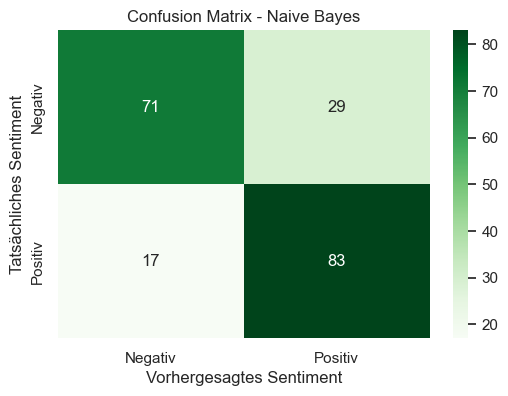

In [37]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negativ", "Positiv"],
    yticklabels=["Negativ", "Positiv"]
)

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Vorhergesagtes Sentiment")
plt.ylabel("Tatsächliches Sentiment")
plt.show()

### Interpretation der Modellleistung

Das Naive-Bayes-Modell erreicht eine Accuracy von 77 %. Damit liegt es leicht unter der logistischen Regression, die 79,5 % erreicht hat.

Für negative Bewertungen (`0`) erzielt Naive Bayes eine Precision von 0,81 und einen Recall von 0,71.
Das bedeutet, dass negative Vorhersagen zwar relativ zuverlässig sind, aber nur 71 % aller tatsächlich negativen Bewertungen erkannt werden.

Für positive Bewertungen (`1`) erreicht das Modell eine Precision von 0,74 und einen Recall von 0,83.
Naive Bayes erkennt positive Bewertungen also besser als negative Bewertungen.

Aus geschäftlicher Sicht ist der niedrigere Recall für negative Bewertungen problematisch, da kritisches Kundenfeedback eher übersehen werden könnte.
Da die logistische Regression sowohl eine höhere Gesamtgenauigkeit als auch einen besseren Recall für negative Bewertungen erreicht, ist sie für dieses Projekt die bessere Wahl.

## Modellvergleich

Um das beste Modell für die Sentiment-Analyse auszuwählen, werden die Ergebnisse der logistischen Regression und des Naive-Bayes-Modells miteinander verglichen.

Verglichen werden Accuracy, Precision, Recall und F1-Score.
Besonders wichtig ist der Recall der negativen Klasse, da negative Bewertungen Hinweise auf mögliche Serviceprobleme enthalten.

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log_reg),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision Negative": [
        precision_score(y_test, y_pred_log_reg, pos_label=0),
        precision_score(y_test, y_pred_nb, pos_label=0)
    ],
    "Recall Negative": [
        recall_score(y_test, y_pred_log_reg, pos_label=0),
        recall_score(y_test, y_pred_nb, pos_label=0)
    ],
    "F1 Negative": [
        f1_score(y_test, y_pred_log_reg, pos_label=0),
        f1_score(y_test, y_pred_nb, pos_label=0)
    ],
    "Precision Positive": [
        precision_score(y_test, y_pred_log_reg, pos_label=1),
        precision_score(y_test, y_pred_nb, pos_label=1)
    ],
    "Recall Positive": [
        recall_score(y_test, y_pred_log_reg, pos_label=1),
        recall_score(y_test, y_pred_nb, pos_label=1)
    ],
    "F1 Positive": [
        f1_score(y_test, y_pred_log_reg, pos_label=1),
        f1_score(y_test, y_pred_nb, pos_label=1)
    ]
})

model_results

,Model,Accuracy,Precision Negative,Recall Negative,F1 Negative,Precision Positive,Recall Positive,F1 Positive
0,Logistic Regression,0.795,0.810526,0.77,0.789744,0.780952,0.82,0.800000
1,Naive Bayes,0.770,0.806818,0.71,0.755319,0.741071,0.83,0.783019


Die Tabelle fasst die wichtigsten Bewertungsmetriken beider Modelle zusammen.

Neben der allgemeinen Accuracy werden Precision, Recall und F1-Score getrennt für negative und positive Bewertungen betrachtet.

Diese getrennte Betrachtung ist wichtig, weil das Projekt nicht nur möglichst viele Bewertungen korrekt klassifizieren soll.
Für das Restaurant ist besonders relevant, negative Bewertungen zuverlässig zu erkennen, damit Probleme im Service oder bei der Qualität nicht übersehen werden.

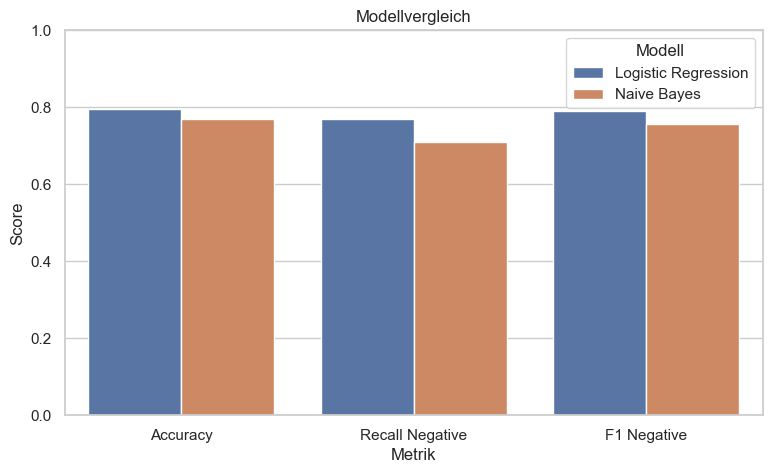

In [40]:
# Visualisierung des Modellvergleichs
model_results_melted = model_results.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Recall Negative", "F1 Negative"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=model_results_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Modellvergleich")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Metrik")
plt.legend(title="Modell")
plt.show()


Die logistische Regression erzielt im Vergleich zu Naive Bayes die bessere Gesamtleistung.

Sie erreicht eine höhere Accuracy und erkennt negative Bewertungen zuverlässiger.
Da negative Bewertungen für das Restaurant besonders wichtig sind, wird die logistische Regression als finales Modell ausgewählt.

Das Modell bietet damit eine solide Grundlage, um Kundenfeedback automatisch zu klassifizieren und kritische Rückmeldungen schneller sichtbar zu machen.

## Vorhersagen für neue Bewertungen

Im nächsten Schritt wird das ausgewählte Logistic-Regression-Modell auf neue Beispielbewertungen angewendet.

Dabei muss jede neue Bewertung dieselben Verarbeitungsschritte durchlaufen wie die Trainingsdaten:

1. Text bereinigen
2. Text mit dem bereits trainierten TF-IDF-Vektorisierer umwandeln
3. Sentiment mit dem trainierten Modell vorhersagen

In [41]:
# Funktion erstellen
def predict_sentiment(review):
    cleaned_review = clean_text(review)
    review_tfidf = tfidf.transform([cleaned_review])

    prediction = log_reg.predict(review_tfidf)[0]
    probabilities = log_reg.predict_proba(review_tfidf)[0]

    sentiment = "Positiv" if prediction == 1 else "Negativ"
    confidence = probabilities[prediction]

    return {
        "Bewertung": review,
        "Bereinigter Text": cleaned_review,
        "Vorhersage": sentiment,
        "Wahrscheinlichkeit": f"{confidence:.1%}"
    }

Die Funktion `predict_sentiment()` nimmt eine neue Bewertung entgegen und gibt die Modellvorhersage zurück.

Mit `clean_text()` wird der Text genau wie die Trainingsdaten bereinigt.

`tfidf.transform()` wandelt die Bewertung in numerische Merkmale um. Dabei wird bewusst nicht erneut `fit_transform()` verwendet: Das bereits erlernte Vokabular des Trainingsdatensatzes soll unverändert bleiben.

`predict()` liefert die vorhergesagte Klasse.

Mit `predict_proba()` werden zusätzlich die geschätzten Wahrscheinlichkeiten für beide Klassen berechnet. So lässt sich erkennen, wie sicher sich das Modell bei seiner Vorhersage ist.

In [42]:
# mehrere Beispiele testen
example_reviews = [
    "The food was delicious and the staff was very friendly."
    "The service was slow and the meal was could."
    "The restaurant was nice, but the food was too expensive"
    "I would definitely come back again."
]

predictions = pd.DataFrame(
    [predict_sentiment(review) for review in example_reviews]
)

predictions


,Bewertung,Bereinigter Text,Vorhersage,Wahrscheinlichkeit
0,The food was delicious and the staff was very ...,food delicious staff friendlythe service slow ...,Positiv,68.7%


### Interpretation der Beispielvorhersagen

Das Modell kann neue Bewertungen automatisch als positiv oder negativ einordnen.

Eindeutig formulierte Bewertungen sind für das Modell meist leichter zu klassifizieren.
Bewertungen mit gemischten Aussagen stellen eine größere Herausforderung dar. Ein Satz kann beispielsweise sowohl eine positive Aussage zur Atmosphäre als auch Kritik am Preis enthalten.

Die ausgegebene Wahrscheinlichkeit sollte nicht als absolute Gewissheit verstanden werden. Sie ist vielmehr ein Hinweis darauf, wie eindeutig die Bewertung aus Sicht des Modells ist.

In [43]:
predict_sentiment("The pasta was amazing, but we waited far too long.")

{'Bewertung': 'The pasta was amazing, but we waited far too long.',
 'Bereinigter Text': 'pasta amazing waited far long',
 'Vorhersage': 'Negativ',
 'Wahrscheinlichkeit': '52.8%'}

## Geschäftlicher Nutzen

Das entwickelte Modell kann Restaurantbewertungen automatisiert als positiv oder negativ klassifizieren. Dadurch erhält das Restaurant schneller einen Überblick über die Kundenzufriedenheit und kann kritisches Feedback gezielt priorisieren.

Besonders häufig genannte negative Begriffe können Hinweise auf wiederkehrende Probleme geben, zum Beispiel:

- lange Wartezeiten
- unfreundlicher Service
- unzureichende Qualität oder Temperatur der Speisen
- ungünstiges Preis-Leistungs-Verhältnis

Das Modell ersetzt keine persönliche Prüfung der Bewertungen. Es kann jedoch als unterstützendes Werkzeug dienen: Negative Bewertungen werden automatisch markiert und anschließend von Mitarbeitenden genauer analysiert.

Da ein Teil der negativen Bewertungen noch nicht korrekt erkannt wird, sollten Bewertungen mit geringer Vorhersagewahrscheinlichkeit ebenfalls manuell geprüft werden.

## Fazit

In diesem Projekt wurde ein Machine-Learning-Modell zur Sentiment-Analyse von Restaurantbewertungen entwickelt.

Der Datensatz umfasst 1000 englischsprachige Bewertungen und ist mit jeweils 500 positiven und negativen Bewertungen vollständig ausgeglichen. Nach der explorativen Datenanalyse wurden die Texte bereinigt und mithilfe von TF-IDF in numerische Merkmale umgewandelt.

Anschließend wurden zwei Klassifikationsmodelle verglichen:

| Modell | Accuracy | Recall für negative Bewertungen |
|---|---:|---:|
| Logistic Regression | 79,5 % | 77 % |
| Naive Bayes | 77,0 % | 71 % |

Die logistische Regression erzielt insgesamt die besseren Ergebnisse und erkennt negative Bewertungen zuverlässiger. Sie wurde deshalb als finales Modell ausgewählt.

Das Projekt zeigt, wie Kundenfeedback mithilfe von Natural Language Processing effizient ausgewertet und als Grundlage für konkrete Verbesserungsmaßnahmen genutzt werden kann.

## Einschränkungen und mögliche Erweiterungen

Das Modell liefert eine solide Grundlage, hat aber noch Verbesserungspotenzial:

- Der Datensatz ist mit 1000 Bewertungen relativ klein.
- Das Modell wurde nur mit englischsprachigen Bewertungen trainiert.
- Gemischte oder ironische Aussagen können schwer zu klassifizieren sein.
- Die Daten enthalten lediglich ein binäres Sentiment und keine detaillierten Kategorien wie Service, Qualität, Preis oder Atmosphäre.

Mögliche nächste Schritte:

- Training mit einem größeren und vielfältigeren Datensatz
- Optimierung der Modellparameter
- Untersuchung von Wortkombinationen wie "not good" mithilfe von N-Grammen
- Vergleich mit weiteren Modellen
- Entwicklung einer mehrsprachigen Lösung
- Ergänzung einer thematischen Analyse, um Kritik automatisch Kategorien zuzuordnen

In [44]:
# noch eine kleine Verbesserung : TF-IDF mit Zweier-Wortkombinationen. So kann das Modell Ausdrücke wie not good besser erfassen.
tfidf_ngrams = TfidfVectorizer(
    max_features=1500,
    ngram_range=(1, 2),
)
# ngram_range=(1, 2) bedeutet:
# Das Modell berücksichtigt sowohl einzelne Wörter als auch Kombinationen aus zwei aufeinanderfolgenden Wörtern.

X_train_tfidf_ngrams = tfidf_ngrams.fit_transform(X_train)
X_test_tfidf_ngrams = tfidf_ngrams.transform(X_test)

log_reg_ngrams = LogisticRegression(max_iter=1000)
log_reg_ngrams.fit(X_train_tfidf_ngrams, y_train)

y_pred_ngrams = log_reg_ngrams.predict(X_test_tfidf_ngrams)

print("Accauracy:", accuracy_score(y_test, y_pred_ngrams))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ngrams))


Accauracy: 0.795

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       100
           1       0.78      0.83      0.80       100

    accuracy                           0.80       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.80      0.79       200



### Ergebnis der N-Gramm-Erweiterung

Zusätzlich wurde geprüft, ob Wortkombinationen aus jeweils zwei aufeinanderfolgenden Wörtern die Modellleistung verbessern. Dadurch können Ausdrücke wie "not good" gemeinsam berücksichtigt werden.

Die Accuracy bleibt mit 79,5 % unverändert. Der Recall für negative Bewertungen sinkt leicht von 77 % auf 76 %, während der Recall für positive Bewertungen geringfügig von 82 % auf 83 % steigt.

Da negative Bewertungen für die geschäftliche Anwendung besonders relevant sind, wird weiterhin die ursprüngliche logistische Regression mit einzelnen Wörtern als finales Modell verwendet.

Die Erweiterung zeigt, dass zusätzliche Merkmale nicht automatisch zu einer besseren Modellleistung führen. Ihr Nutzen sollte stets anhand der relevanten Metriken geprüft werden.

In [46]:
import joblib

joblib.dump(log_reg, "log_reg_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Modell und TF-IDF-Vektorisierer wurden gespeichert.")

Modell und TF-IDF-Vektorisierer wurden gespeichert.


In [47]:
import os

print(os.getcwd())

/Users/michaelakittel/PythonProject1/PythonProject5/notebooks


In [50]:
from pathlib import Path
import joblib

project_dir = Path("/Users/michaelakittel/PythonProject1/PythonProject5")

joblib.dump(log_reg, project_dir / "log_reg_model.pkl")
joblib.dump(tfidf, project_dir / "tfidf_vectorizer.pkl")

print("Modell gespeichert:", project_dir / "log_reg_model.pkl")
print("Vektorisierer gespeichert:", project_dir / "tfidf_vectorizer.pkl")

Modell gespeichert: /Users/michaelakittel/PythonProject1/PythonProject5/log_reg_model.pkl
Vektorisierer gespeichert: /Users/michaelakittel/PythonProject1/PythonProject5/tfidf_vectorizer.pkl
